In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Split
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve)

# Cargar dataset procesado
credit_df = pd.read_csv("../data/processed/credit_df_processed.csv")
credit_df.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Not Graduate,self_employed_ Yes
0,-0.294102,1.617979,1.633052,0.192617,1.032792,-0.780249,2.877289,0.832028,0.930304,1,0,0
1,-1.473548,-0.341750,-0.324414,-0.508091,-1.061051,-0.734111,-0.631921,-0.694993,-0.515936,0,1,1
2,0.295621,1.439822,1.610933,1.594031,-0.544840,-0.057408,-0.107818,1.996520,2.407316,0,0,0
3,0.295621,1.119139,1.721525,-0.508091,-0.771045,1.649729,-0.381263,0.897943,0.899533,0,0,0
4,1.475067,1.689242,1.002681,1.594031,-1.264055,0.757711,0.735304,1.568075,0.007172,0,1,1


In [2]:
# Variables predictoras
X = credit_df.drop(columns=['loan_status'])

# Variable objetivo
y = credit_df['loan_status']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)
#No se utilizó stratified split debido a la distribución balanceada de la variable objetivo.   (stratify=y)

In [4]:
rf_clf = RandomForestClassifier(n_estimators = 1000, random_state = 42, n_jobs = -1, max_depth = 5)
rf_clf.fit(X_train, y_train)



RandomForestClassifier(max_depth=5, n_estimators=1000, n_jobs=-1,
                       random_state=42)

In [5]:
#Predicciones y Probabilidad

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:,1]

In [6]:
y_pred_rf #pronosticos

array([0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,

In [7]:
y_prob_rf #probabilidades

array([0.14174545, 0.91377363, 0.13584224, 0.92384534, 0.90835498,
       0.89854961, 0.90544687, 0.12982056, 0.91137455, 0.13717326,
       0.15007959, 0.90678949, 0.90999498, 0.15939783, 0.13128907,
       0.91126014, 0.96519558, 0.46787137, 0.50331979, 0.13459213,
       0.90764563, 0.14178158, 0.15482094, 0.13885956, 0.90686709,
       0.91648005, 0.90886546, 0.90520015, 0.91559572, 0.13480088,
       0.90744281, 0.14050689, 0.14961175, 0.91078807, 0.13248701,
       0.13346013, 0.91898451, 0.90596901, 0.92429425, 0.13973627,
       0.13510725, 0.9498668 , 0.96023692, 0.90889245, 0.5209162 ,
       0.91500161, 0.93277191, 0.93834418, 0.91105069, 0.13898721,
       0.95988729, 0.43061305, 0.13205198, 0.90992111, 0.88760288,
       0.90790644, 0.90727056, 0.90861255, 0.43652686, 0.9124062 ,
       0.93616027, 0.92029664, 0.1435269 , 0.1290677 , 0.14156855,
       0.91834736, 0.91904389, 0.93646544, 0.86209552, 0.95125016,
       0.90679812, 0.87018564, 0.94833882, 0.90673925, 0.13039

In [8]:
#Evaluacion del modelo

print("\nEvaluacion para el Modelo Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"Roc-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")


Evaluacion para el Modelo Random Forest
Accuracy: 0.9707
Precision: 0.9776
Recall: 0.9757
F1-Score: 0.9767
Roc-AUC: 0.9977


### Modelo seleccionado: Random Forest

- Supera ampliamente a la regresión logística en todas las métricas.

- Minimiza el riesgo financiero (bajos falsos positivos).

- Maximiza captación de clientes confiables (alto recall).

- Alta capacidad para capturar relaciones no lineales.

El modelo Random Forest demuestra un desempeño sobresaliente para tareas de credit scoring, logrando un balance óptimo entre riesgo y rentabilidad.

*Pese al excelente resultado, un ROC-AUC tan alto puede indicar un dataset muy limpio o potencial riesgo de overfitting, por lo que el modelo debe validarse con cross-validation y datos fuera de muestra.*

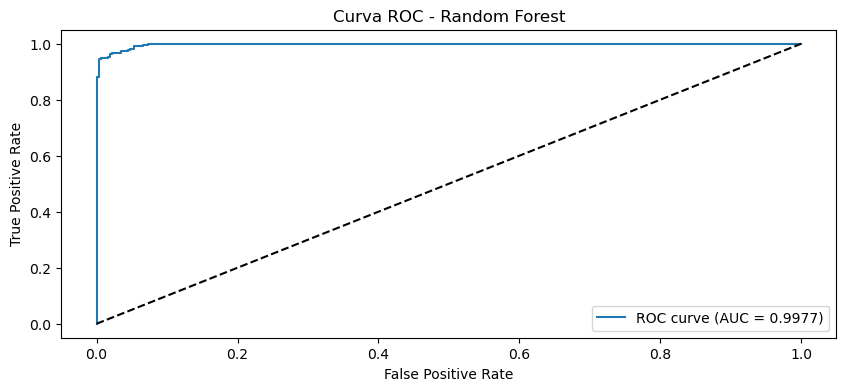

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(10,4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.show()

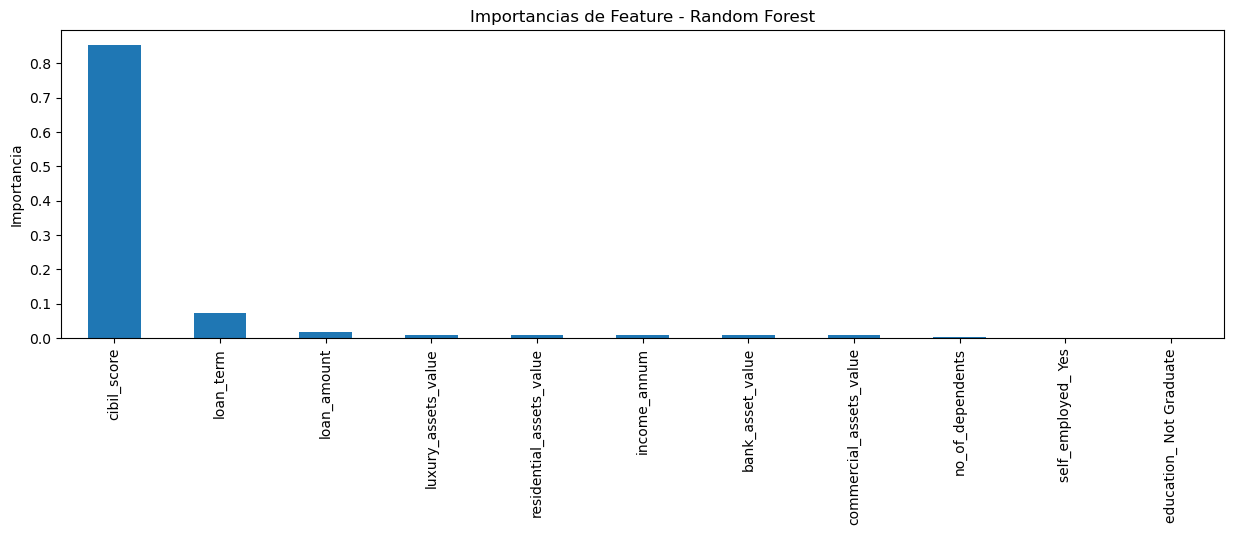

In [10]:
# Importancia de las caracteristicas (Features)

feature_importance = pd.Series(rf_clf.feature_importances_, index = X.columns).sort_values(ascending = False)
plt.figure(figsize = (15, 4))
feature_importance.plot(kind = 'bar')
plt.title('Importancias de Feature - Random Forest')
plt.ylabel('Importancia')
plt.show()

El modelo depende casi exclusivamente de cibil_score para tomar decisiones.
Si conozco el CIBIL score (Historial crediticio), casi no necesito el resto de las variables para predecir el default.
Eso explica perfectamente por qué hay un ROC-AUC altísimo (0.9977), Accuracy y métricas casi perfectas.

*El modelo se apoya fuertemente en un score externo, lo cual explica su alto desempeño. En un escenario real, evaluaría el modelo también sin esa variable para entender el aporte marginal del resto de las features.*

## Conclusiones – Random Forest

El modelo Random Forest presenta un desempeño sobresaliente en todas las métricas evaluadas,
superando ampliamente a la regresión logística.

El alto valor de ROC-AUC sugiere una fuerte capacidad discriminatoria, explicada principalmente
por la variable `cibil_score`, la cual concentra gran parte del poder predictivo del modelo.

Este resultado motiva la evaluación de la estabilidad del modelo eliminando dicha variable,
con el objetivo de analizar su dependencia y robustez ante escenarios más realistas.


In [11]:
import pickle

with open("../models/random_forest.pkl", "wb") as f:
    pickle.dump(rf_clf, f)